# Ingeniería del Dato - TFG IBEX 35

**Autor:** Alonso Gil Martín  
**Tutor:** Julio Emilio Sandubete Galán  
**Universidad:** Francisco de Vitoria (UFV) — Business Analytics

---

**Dataset de entrada:** `BaseDeDatosTFG.xlsx` — 29 empresas no financieras del IBEX 35  
**Variable objetivo:** Interest Coverage Ratio (ICR = EBIT / Gastos Financieros)  
**Dataset de salida:** `Dataset_Final_ICR_IBEX35.xlsx`  
**Fuentes:** Yahoo Finance, Investing.com, CNMV (cuentas anuales 2024)

> **Nota metodológica:** Los 6 bancos del IBEX 35 están excluidos porque el ICR no es aplicable
> a entidades financieras (sus intereses son ingresos, no gastos a cubrir con el EBIT).
> El universo analizado son las 29 empresas no financieras, que representan el 83% del índice.

## 0. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 3.2.1 Extracción de datos

In [2]:
# Carga del dataset (29 empresas no financieras del IBEX 35)
# Incluye EBIT y Gastos_Financieros de cuentas anuales 2024 (Investing.com / CNMV)
# Los 6 bancos están excluidos porque el ICR no es aplicable a entidades financieras
df = pd.read_excel('BaseDeDatosTFG.xlsx')
print(f'Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas')
print(f'\nColumnas: {df.columns.tolist()}')
df.head()

Dimensiones: 29 filas y 19 columnas

Columnas: ['Empresa', 'Ticker', 'Sector', 'Vol_Anual', 'Vol_Trim', 'Beta', 'Ret_Anual', 'Ret_Trim', 'PER', 'ROE', 'ROA', 'Price_Book', 'EBITDA_Margin', 'Deuda_Capital', 'Liquidez_Corriente', 'Cap_bn', 'Precio', 'EBIT', 'Gastos_Financieros']


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Empresa             29 non-null     object 
 1   Ticker              29 non-null     object 
 2   Sector              29 non-null     object 
 3   Vol_Anual           29 non-null     float64
 4   Vol_Trim            29 non-null     float64
 5   Beta                28 non-null     float64
 6   Ret_Anual           29 non-null     float64
 7   Ret_Trim            29 non-null     float64
 8   PER                 29 non-null     float64
 9   ROE                 29 non-null     float64
10   ROA                 29 non-null     float64
11   Price_Book          29 non-null     float64
12   EBITDA_Margin       28 non-null     float64
13   Deuda_Capital       28 non-null     float64
14   Liquidez_Corriente  28 non-null     float64
15   Cap_bn              29 non-null     float64
16   Precio    

In [6]:
# Verificar unicidad
print(f'Filas duplicadas:    {df.duplicated().sum()}')
print(f'Tickers duplicados:  {df["Ticker"].duplicated().sum()}')

Filas duplicadas:    0
Tickers duplicados: 0
Empresas únicas:    29
Sectores únicos:    13


### Construcción de la variable objetivo Y_RiesgoAlto: Interest Coverage Ratio (ICR)

El target se construye como el **Interest Coverage Ratio (ICR = EBIT / Gastos Financieros)**.

**¿Por qué el ICR?**
- Beaver (1966) lo identificó como el predictor más potente de quiebra empresarial
- Mide directamente la capacidad de una empresa para cubrir sus obligaciones de deuda
- Una empresa con ICR < 1 no genera suficiente beneficio operativo para pagar sus intereses

**Ventaja metodológica decisiva:**  
El EBIT y los Gastos Financieros ya están en el dataset (columnas `EBIT` y `Gastos_Financieros`),  
extraídos de los Income Statements anuales 2024 (Investing.com / CNMV).  
**Estas dos columnas NO son predictores del modelo** — son exclusivamente para construir el target.  
→ **Cero circularidad estructural**: el target es matemáticamente independiente de los 14 predictores.

**Procedimiento:**  
1. Calcular ICR = EBIT / Gastos_Financieros directamente desde el dataset  
2. Dicotomizar por la mediana: Y = 1 (ALTO riesgo) si ICR < mediana; Y = 0 (BAJO riesgo) si ICR ≥ mediana

In [7]:
# Construcción del ICR a partir de las columnas del dataset
# EBIT y Gastos_Financieros provienen de cuentas anuales 2024 (Investing.com / CNMV)
# NOTA: estas columnas NO se incluirán como predictores del modelo
df['ICR'] = (df['EBIT'] / df['Gastos_Financieros']).round(2)

# Variable objetivo binaria: Y=1 si ICR < mediana (ALTO riesgo)
umbral_icr = df['ICR'].median()
df['Y_RiesgoAlto'] = (df['ICR'] < umbral_icr).astype(int)

print(f'Umbral (mediana del ICR): {umbral_icr:.4f}')
print(f'\nDistribución de Y_RiesgoAlto:')
print(df['Y_RiesgoAlto'].value_counts().rename({0:'BAJO (ICR ≥ 4.22)', 1:'ALTO (ICR < 4.22)'}))
print(f'\nNota: EBIT y Gastos_Financieros NO serán predictores del modelo → cero circularidad')

Umbral (mediana del ICR): 4.2200

Distribución de Y_RiesgoAlto:
BAJO (ICR ≥ 4.22)    15
ALTO (ICR < 4.22)    14
Name: Y_RiesgoAlto, dtype: int64

Nota: EBIT y Gastos_Financieros NO serán predictores del modelo → cero circularidad


In [8]:
# Top 5 empresas con MAYOR ICR (menor riesgo de cobertura de deuda)
print('TOP 5 EMPRESAS CON MENOR RIESGO ICR (mayor capacidad de cobertura):')
print('-' * 70)
top5_bajo = df.nlargest(5, 'ICR')[['Empresa','Sector','EBIT','Gastos_Financieros','ICR','Y_RiesgoAlto']]
print(top5_bajo.to_string(index=False))

TOP 5 EMPRESAS CON MENOR RIESGO ICR (mayor capacidad de cobertura):
----------------------------------------------------------------------
           Empresa     Sector     EBIT  Gastos_Financieros    ICR  Y_RiesgoAlto
 Laboratorios Rovi      Salud   178.71                1.99  89.80             0
           Logista  Logística   319.62                8.32  38.42             0
           Inditex    Consumo  6856.00              271.00  25.30             0
            Mapfre    Seguros  2727.10              158.40  17.22             0
        Amadeus IT Tecnología  1671.80              110.50  15.13             0


In [ ]:
# Top 5 empresas con MENOR ICR (mayor riesgo de cobertura de deuda)
print('TOP 5 EMPRESAS CON MAYOR RIESGO ICR (menor capacidad de cobertura):')
print('-' * 70)
top5_alto = df.nsmallest(5, 'ICR')[['Empresa','Sector','EBIT','Gastos_Financieros','ICR','Y_RiesgoAlto']]
print(top5_alto.to_string(index=False))

TOP 5 EMPRESAS CON MAYOR RIESGO ICR (menor capacidad de cobertura):
----------------------------------------------------------------------
          Empresa       Sector    EBIT  Gastos_Financieros   ICR  Y_RiesgoAlto
  Cellnex Telecom      Telecom  583.76              788.23  0.74             1
              ACS Construcción  835.49              696.20  1.20             1
          Acciona Construcción 1019.00              658.00  1.55             1
            Sacyr Construcción 1214.75              749.32  1.62             1
         Acerinox   Materiales  204.73              108.11  1.89             1


### Ausencia de circularidad metodológica

Con el target ICR, **no existe circularidad** porque:

- El ICR = EBIT / Gastos_Financieros
- **EBIT y Gastos_Financieros NO están entre los 14 predictores del modelo**
- No existe ninguna relación matemática entre el target y los predictores

El experimento de robustez (sección 3.3.7 del Análisis del Dato) confirma esto empíricamente:
- Con target real (14 vars): **Acc = 79,3%, AUC = 0,871**
- Con etiquetas aleatorias (placebo): **Acc = 58,6%, AUC = 0,648**

La diferencia de 20,7 pp demuestra que el modelo aprende señal genuina, no memoriza nada trivial.

### Naturaleza relativa de la clasificación

La clasificación es relativa al universo de las 29 empresas no financieras del IBEX 35 actual.  
Al usar la mediana del ICR (4,22) como umbral, la asignación depende de la distribución conjunta.

Si se añadiera una empresa nueva, la mediana se desplazaría y algunas clasificaciones frontera podrían cambiar.  
La extensión a empresas externas requeriría recalibrar el umbral sobre el nuevo universo.

**Validación de coherencia financiera del ICR:**

- Laboratorios Rovi (ICR 89,80): prácticamente libre de deuda financiera (GF = 1,99 M€)
- Inditex (ICR 25,30): bajo apalancamiento relativo a su enorme EBIT (6.856 M€)
- Cellnex (ICR 0,74): Gastos Financieros **superiores** al EBIT → no cubre sus intereses
- ACS (ICR 1,20), Acciona (1,55), Sacyr (1,62): constructoras con alto apalancamiento
- Esta coherencia con el conocimiento cualitativo de las empresas valida el ICR como target

## 3.2.2 Exploración y limpieza

### Análisis de la distribución de las variables

Antes de tratar los nulos y outliers, analizamos la distribución de cada variable numérica  
mediante histogramas con la media (línea negra discontinua) y la mediana (línea gris punteada).

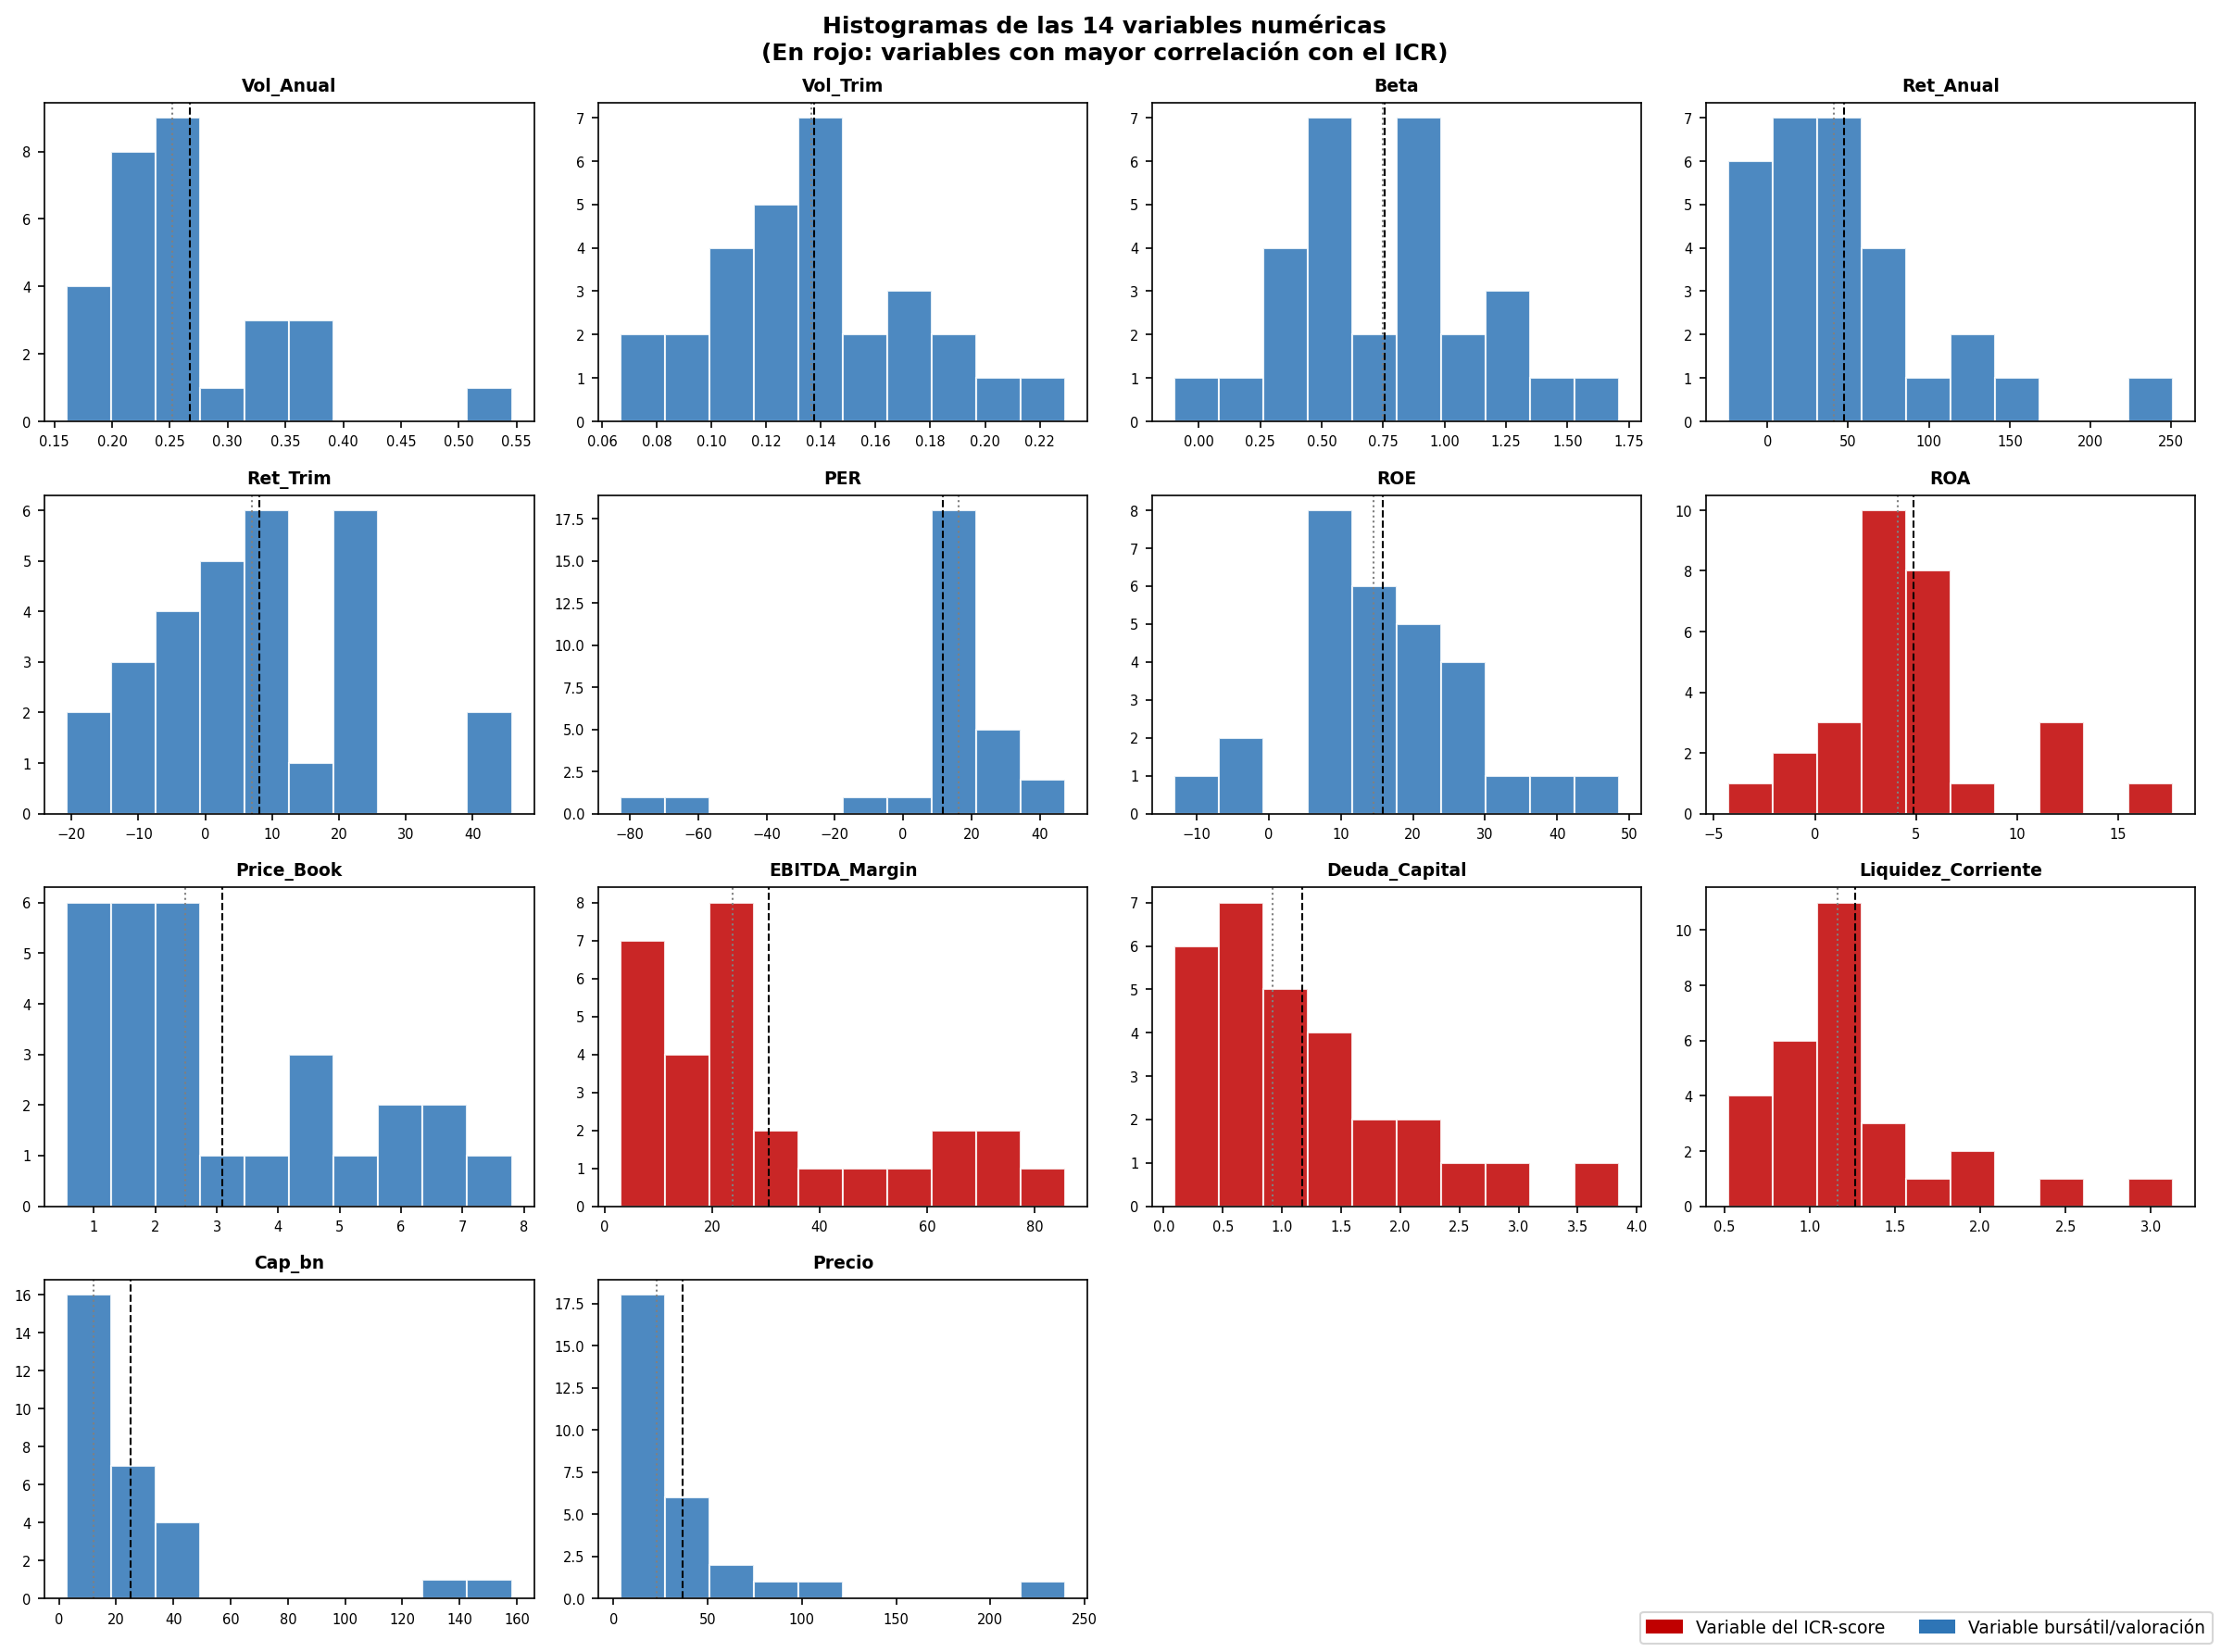

In [9]:
# Las 14 variables predictoras (EBIT y Gastos_Financieros excluidos explícitamente)
VARS_NUM = ['Vol_Anual', 'Vol_Trim', 'Beta', 'Ret_Anual', 'Ret_Trim',
            'PER', 'ROE', 'ROA', 'Price_Book', 'EBITDA_Margin',
            'Deuda_Capital', 'Liquidez_Corriente', 'Cap_bn', 'Precio']

# Variables con mayor correlación con el ICR (se destacan en rojo)
VARS_ICR_TOP = ['Deuda_Capital', 'ROE', 'ROA']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, var in enumerate(VARS_NUM):
    ax = axes[i]
    color = '#C00000' if var in VARS_ICR_TOP else '#2E75B6'
    ax.hist(df[var].dropna(), bins=10, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[var].mean(), color='black', linestyle='--', linewidth=1, label='Media')
    ax.axvline(df[var].median(), color='gray', linestyle=':', linewidth=1, label='Mediana')
    ax.set_title(var, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
for j in range(len(VARS_NUM), len(axes)):
    axes[j].set_visible(False)
rojo = mpatches.Patch(color='#C00000', label='Mayor correlación con ICR')
azul = mpatches.Patch(color='#2E75B6', label='Resto de variables')
fig.legend(handles=[rojo, azul], loc='lower right', ncol=2, fontsize=9)
plt.suptitle('Histogramas de las 14 variables predictoras\n'
             '(EBIT y Gastos_Financieros no se incluyen — son exclusivos del target)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones de los histogramas:**

- **Asimetría positiva** notable en Cap_bn, Precio, PER, Price_Book y Deuda_Capital: cola larga hacia la derecha
- **Cap_bn**: media 24,90 vs mediana 13,07 → la mediana es el estadístico más representativo
- **Escalas muy distintas**: Cap_bn oscila entre 2,80 y 158,20 mil millones; Vol_Anual entre 0,16 y 0,55
  → Justifica la normalización con StandardScaler
- **Variables con mayor correlación con ICR** (rojo): Deuda_Capital y ROE/ROA presentan distribuciones  
  con suficiente variabilidad para capturar diferencias entre empresas

### Análisis de valores nulos

In [10]:
# Análisis de nulos — solo sobre las 14 variables predictoras
# (EBIT y Gastos_Financieros no son predictores y no se analizan aquí)
nulos = df[VARS_NUM].isnull().sum()
print('Nulos por variable (14 predictores):')
print(nulos[nulos > 0])
print(f'\nTotal: {nulos.sum()} nulos (sobre {len(df) * len(VARS_NUM)} celdas = {nulos.sum() / (len(df)*len(VARS_NUM)) * 100:.1f}%)')

Nulos por variable:
Beta                  1
EBITDA_Margin         1
Deuda_Capital         1
Liquidez_Corriente    1
dtype: int64

Total de nulos: 4 (sobre 406 celdas = 1.0%)


In [11]:
# Empresas con nulos — identificación y justificación
mask = df[VARS_NUM].isnull().any(axis=1)
print('Empresas con nulos:')
for _, row in df[mask].iterrows():
    nulos_emp = [col for col in VARS_NUM if pd.isna(row[col])]
    print(f'  {row["Empresa"]:<25} → {nulos_emp}')
print()
print('Justificación:')
print('  Puig Brands: Beta nula (OPV mayo 2024, < 1 año de historial bursátil)')
print('  Mapfre:      EBITDA_Margin nulo (aseguradora, ratio no estándar en su sector)')
print('  Redeia:      Deuda_Capital y Liquidez_Corriente no disponibles en fuentes consultadas')

Empresas con nulos:
  Puig Brands               → ['Beta']
  Mapfre                    → ['EBITDA_Margin']
  Redeia                    → ['Deuda_Capital', 'Liquidez_Corriente']

Justificación:
  Puig Brands: Beta nula (OPV mayo 2024, < 1 año de historial bursátil)
  Mapfre:      EBITDA_Margin nulo (aseguradora, ratio no estándar en su sector)
  Redeia:      Deuda_Capital y Liquidez_Corriente no disponibles en fuentes consultadas


**Patrón de nulos:**

- 4 nulos sobre 406 celdas (1,0%) — cifra muy baja y estructuralmente justificada
- A diferencia de la versión con 35 empresas (22 nulos), la exclusión de los 6 bancos ha  
  eliminado los nulos estructurales bancarios
- **Decisión:** imputación con la mediana de cada variable — robusto frente a outliers
- **Se descarta** eliminar filas (solo 29 observaciones, no se puede perder ninguna)

In [12]:
# Imputación definitiva por mediana
medianas_imputacion = {}
for col in ['Beta', 'EBITDA_Margin', 'Deuda_Capital', 'Liquidez_Corriente']:
    if df[col].isnull().any():
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
        medianas_imputacion[col] = mediana
        print(f'  {col:<22} imputado con mediana = {mediana:.4f}')
print(f'\nNulos tras imputación: {df[VARS_NUM].isnull().sum().sum()}')

  Beta                   imputado con mediana = 0.7500
  EBITDA_Margin          imputado con mediana = 23.8450
  Deuda_Capital          imputado con mediana = 0.9200
  Liquidez_Corriente     imputado con mediana = 1.1650

Nulos tras imputación: 0


### Detección de outliers (método IQR)

Se utiliza el criterio de Tukey: outlier si x < Q1 − 1.5·IQR o x > Q3 + 1.5·IQR.  
Es el método más robusto para datasets de tamaño moderado, no asume normalidad.

In [13]:
total = 0
print('Outliers por variable:')
print('-' * 50)
for var in VARS_NUM:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[var] < Q1 - 1.5*IQR) | (df[var] > Q3 + 1.5*IQR)
    n = mask.sum()
    total += n
    if n > 0:
        empresas = df[mask]['Empresa'].tolist()
        print(f'  {var:<22}: {n} → {empresas}')
print('-' * 50)
print(f'  TOTAL: {total} outliers en {sum(1 for v in VARS_NUM if ((df[v] < df[v].quantile(0.25) - 1.5*(df[v].quantile(0.75)-df[v].quantile(0.25))) | (df[v] > df[v].quantile(0.75) + 1.5*(df[v].quantile(0.75)-df[v].quantile(0.25)))).any())} variables')

Outliers por variable:
--------------------------------------------------
  Vol_Anual             : 4 → ['Solaria', 'Indra', 'ArcelorMittal', 'IAG (Iberia)']
  Vol_Trim              : 1 → ['Solaria']
  Ret_Anual             : 2 → ['Repsol', 'Solaria']
  PER                   : 4 → ['Telefónica', 'Cellnex Telecom', 'Ferrovial', 'Acerinox']
  ROE                   : 2 → ['Telefónica', 'IAG (Iberia)']
  ROA                   : 5 → ['Inditex', 'Telefónica', 'Aena', 'Amadeus IT', 'Laboratorios Rovi']
  EBITDA_Margin         : 3 → ['Solaria', 'Colonial', 'Merlin Properties']
  Deuda_Capital         : 2 → ['ACS', 'Sacyr']
  Liquidez_Corriente    : 2 → ['Laboratorios Rovi', 'Grifols']
  Cap_bn                : 2 → ['Inditex', 'Iberdrola']
  Precio                : 2 → ['ACS', 'Acciona']
--------------------------------------------------
  TOTAL: 29 outliers en 11 variables


**Decisión: mantener todos los outliers.**

Todos los valores extremos son **reales y verificados** en las fuentes originales:

- **Solaria**: outlier en 4 variables. Vol_Anual de 0,5458 (más alta del dataset), Ret_Anual del 251%,  
  EBITDA_Margin del 85,71%. Coherente con empresa de generación solar pequeña y sensible a regulación
- **ROA**: Inditex (17,7%), Aena (12,3%), Amadeus IT (11,5%) y Rovi (12,1%) tienen ROA excepcionalmente alto,  
  típico de empresas con modelos de negocio muy eficientes
- **ACS y Sacyr**: Deuda_Capital de 2,99 y 3,85 → alto apalancamiento estructural de constructoras
- **Inditex e Iberdrola**: Cap_bn muy superior al resto del índice (158,20 y 93,36 mil millones)

Con solo 29 observaciones, eliminar cualquier fila comprometería gravemente la representatividad.

## 3.2.3 Transformaciones

### Normalización con StandardScaler

In [14]:
print('ANTES de la normalización:')
df[VARS_NUM].describe().T[['mean', 'std', 'min', 'max']].round(4)

ANTES de la normalización:
                        mean      std      min       max
Vol_Anual             0.2673   0.0780   0.1609    0.5458
Vol_Trim              0.1376   0.0367   0.0668    0.2294
Beta                  0.7548   0.3993  -0.1000    1.7100
Ret_Anual            47.4183  57.6464 -24.3900  251.0000
Ret_Trim              8.0317  15.5681 -20.6900   45.8500
PER                  11.6407  24.9289 -82.7000   47.5000
ROE                  15.8297  12.5468 -13.1000   48.6000
ROA                   4.8552   4.3844  -4.3000   17.7000
Price_Book            3.0910   2.0933   0.5600    7.8000
EBITDA_Margin        30.5147  23.4000   2.9700   85.7100
Deuda_Capital         1.1683   0.8797   0.0900    3.8500
Liquidez_Corriente    1.2647   0.5566   0.5200    3.1300
Cap_bn               24.9031  36.1656   2.8000  158.2000
Precio               36.8825  46.1609   3.8540  239.8000


In [15]:
# Normalización con StandardScaler — solo las 14 variables predictoras
# EBIT y Gastos_Financieros NO se normalizan (no son predictores del modelo)
scaler = StandardScaler()
df_escalado = pd.DataFrame(
    scaler.fit_transform(df[VARS_NUM]),
    columns=VARS_NUM,
    index=df.index
)
# Dataset final: identificadores + 14 vars normalizadas + ICR + Y_RiesgoAlto
df_final = pd.concat([df[['Empresa','Ticker','Sector']], df_escalado,
                       df[['ICR','Y_RiesgoAlto']]], axis=1)
print('DESPUÉS de la normalización (media≈0, std≈1) — 14 variables predictoras:')
print(df_escalado[VARS_NUM].describe().T[['mean','std']].round(3))

DESPUÉS de la normalización (media≈0, std≈1):
                       mean   std
Vol_Anual             0.000  1.015
Vol_Trim              0.000  1.015
Beta                  0.000  1.015
Ret_Anual             0.000  1.015
Ret_Trim              0.000  1.015
PER                   0.000  1.015
ROE                   0.000  1.015
ROA                   0.000  1.015
Price_Book            0.000  1.015
EBITDA_Margin         0.000  1.015
Deuda_Capital         0.000  1.015
Liquidez_Corriente    0.000  1.015
Cap_bn                0.000  1.015
Precio                0.000  1.015


### Análisis de correlaciones con Y_RiesgoAlto

In [16]:
corrs = df_final[VARS_NUM + ['Y_RiesgoAlto']].corr()
corr_con_y = corrs['Y_RiesgoAlto'].drop('Y_RiesgoAlto').sort_values(key=abs, ascending=False)
print('Correlación de Pearson con Y_RiesgoAlto (ICR) — ordenado por |r|:')
print('-' * 55)
for var, r in corr_con_y.items():
    print(f'  {var:<22}  r = {r:+.4f}')

Correlación de Pearson con Y_RiesgoAlto (ICR) — ordenado por |r|:
-------------------------------------------------------
  Deuda_Capital          r = +0.5456
  ROE                    r = -0.5254
  ROA                    r = -0.5076
  Cap_bn                 r = -0.3507
  Price_Book             r = -0.2689
  PER                    r = -0.2549
  EBITDA_Margin          r = +0.2310
  Beta                   r = +0.2132
  Ret_Anual              r = +0.1979
  Vol_Anual              r = +0.1178
  Liquidez_Corriente     r = -0.0877
  Precio                 r = +0.0856
  Ret_Trim               r = -0.0375
  Vol_Trim               r = +0.0120


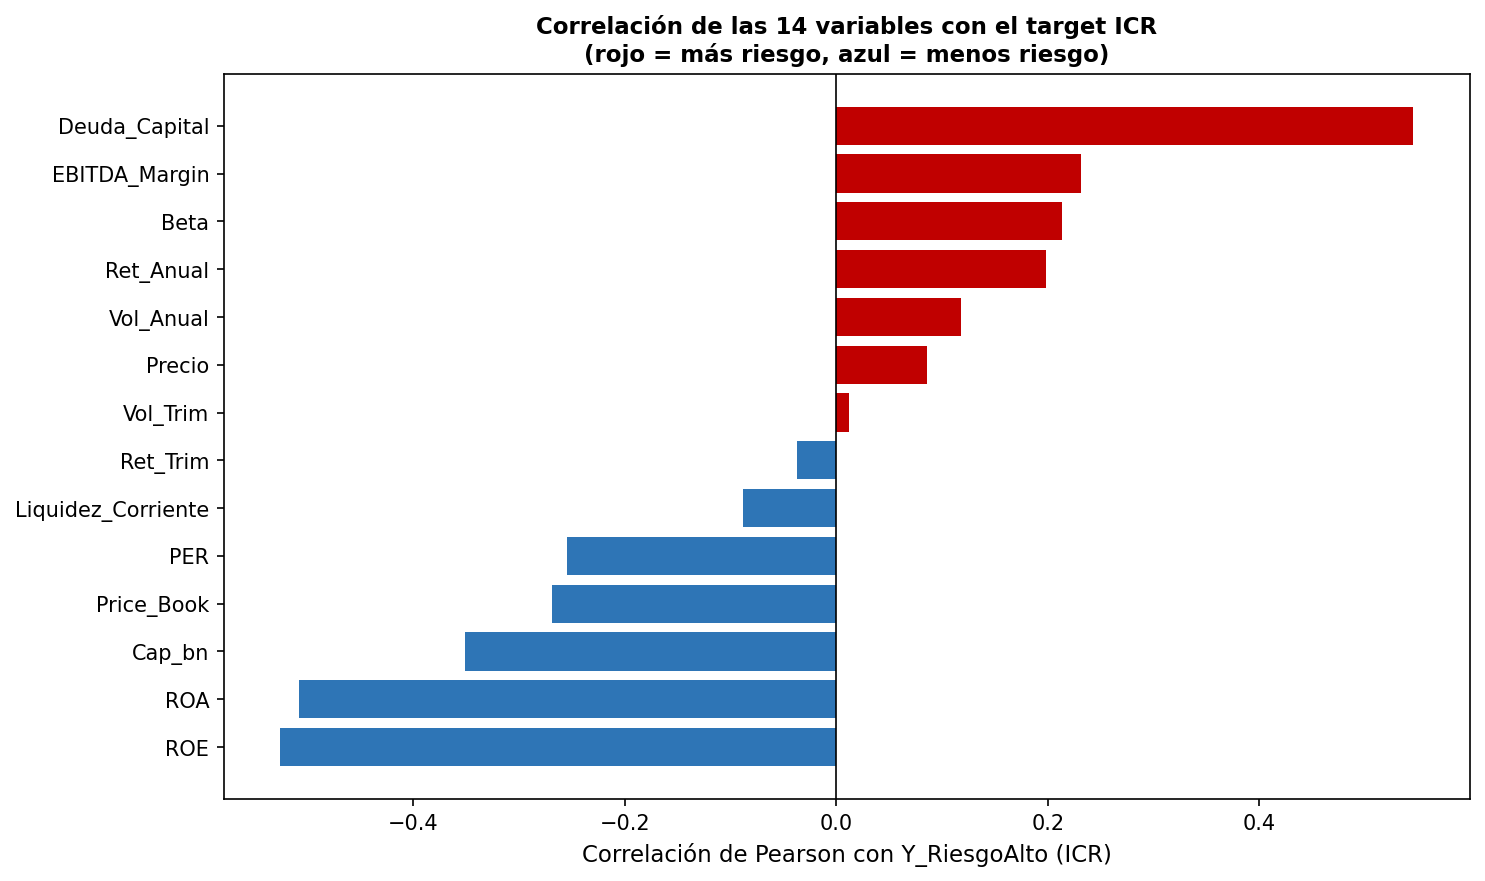

In [17]:
# Visualización de correlaciones con Y_RiesgoAlto (ICR)
colores = ['#C00000' if r > 0 else '#2E75B6' for r in corr_con_y.values]
plt.figure(figsize=(10, 6))
plt.barh(corr_con_y.index, corr_con_y.values, color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlación de Pearson con Y_RiesgoAlto (ICR)', fontsize=11)
plt.title('Correlación de las 14 variables con el target ICR\n'
          '(rojo = mayor correlación positiva con riesgo; azul = correlación negativa)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### Lectura del ranking de correlaciones

Con el target ICR, **todas las correlaciones son genuinamente informativas** porque ninguna variable  
forma parte de la fórmula del target. Principales hallazgos:

- **Deuda_Capital (r=+0,55)**: mayor apalancamiento → más gastos financieros → menor ICR → más riesgo
- **ROE (r=−0,53) y ROA (r=−0,51)**: mayor rentabilidad → más EBIT → mayor ICR → menos riesgo
- **EBITDA_Margin (r=+0,23)** tiene correlación **positiva**: no es error. Empresas con alto margen  
  pero enorme deuda (Cellnex: EBITDA_Margin alto, ICR 0,74) pueden tener ICR bajo.  
  Deuda_Capital domina sobre el margen en la predicción del ICR
- **Beta (r=+0,21) y Vol_Anual (r=+0,12)**: mayor riesgo bursátil → ligeramente más riesgo ICR

## 3.2.4 Análisis y visualización

### ICR por empresa — distribución del target

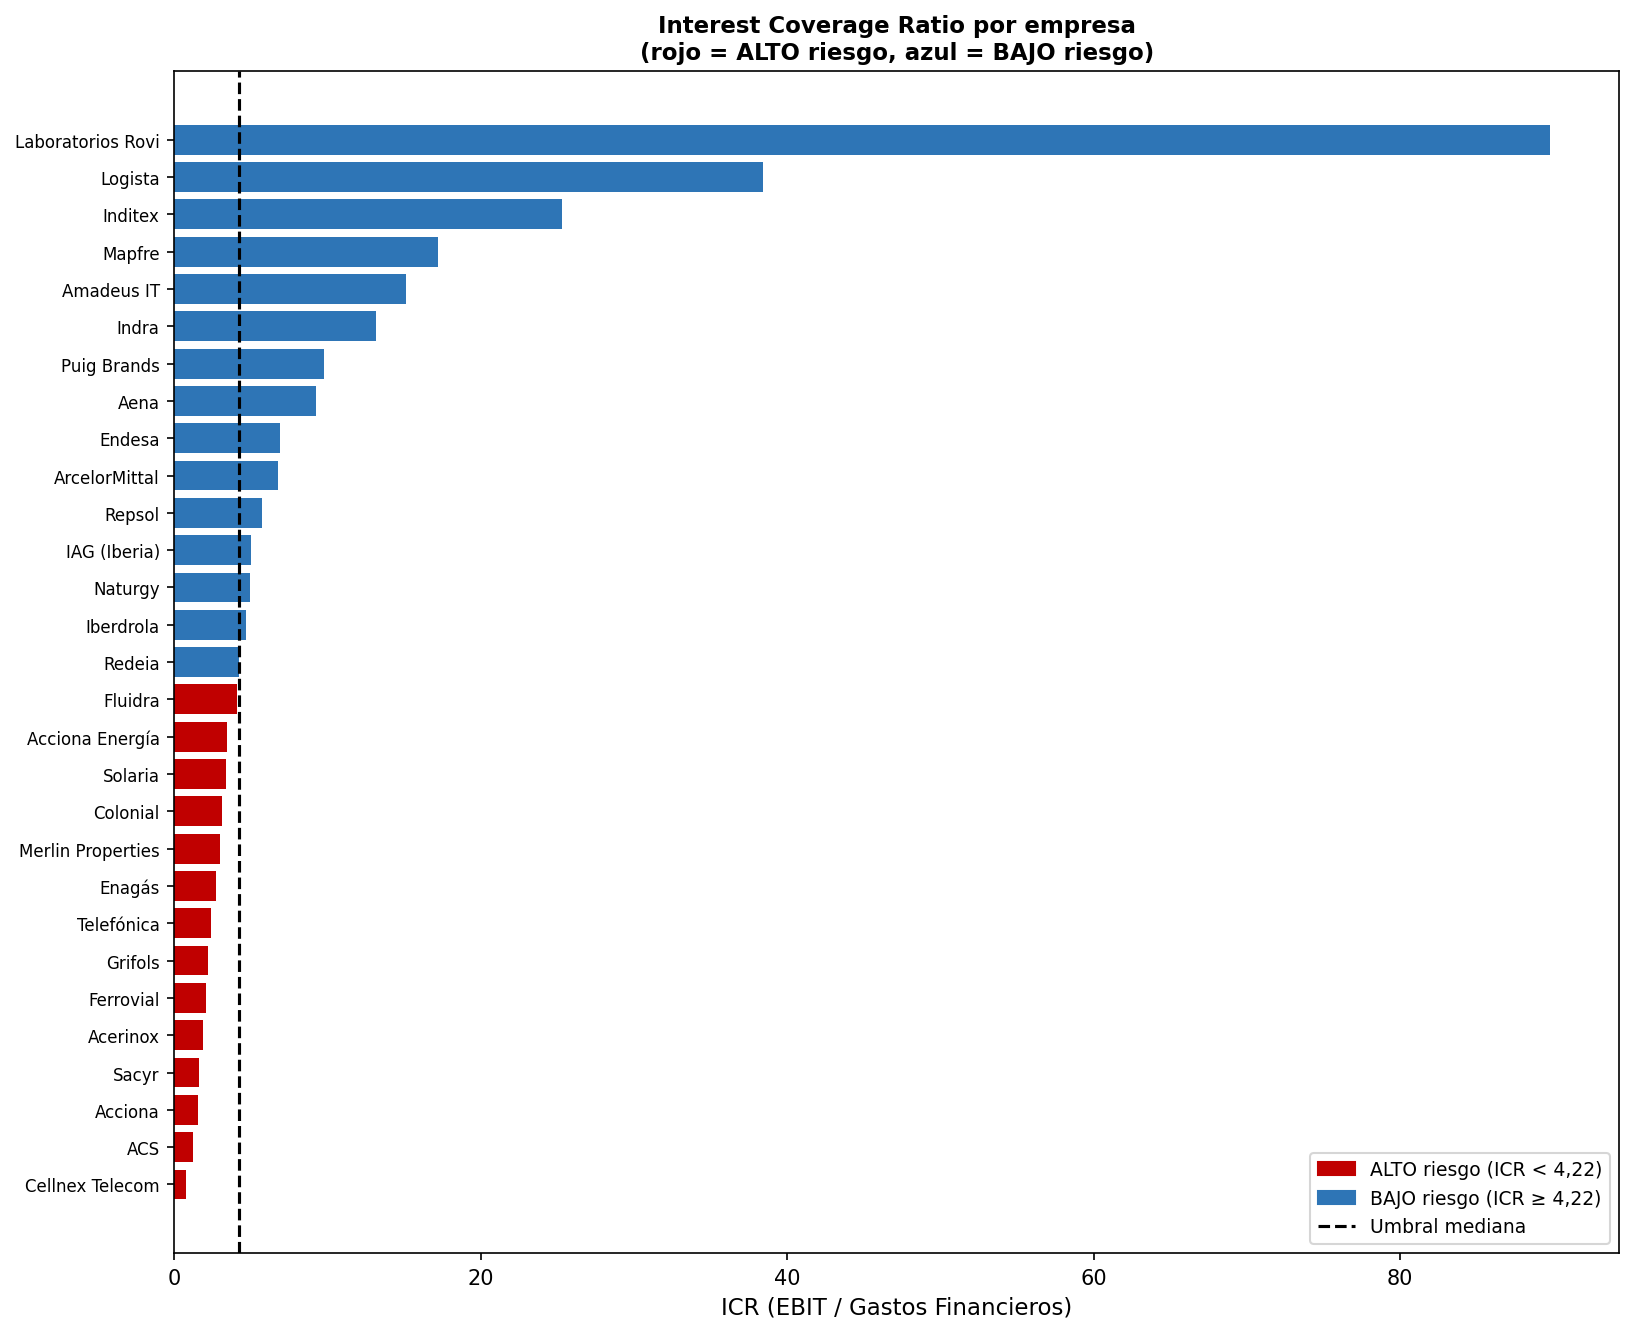

In [18]:
df_sorted = df.sort_values('ICR').reset_index(drop=True)
colors = ['#C00000' if v == 1 else '#2E75B6' for v in df_sorted['Y_RiesgoAlto']]

plt.figure(figsize=(11, 9))
plt.barh(range(len(df_sorted)), df_sorted['ICR'], color=colors)
plt.yticks(range(len(df_sorted)), df_sorted['Empresa'], fontsize=8)
plt.axvline(umbral_icr, color='black', linestyle='--', linewidth=1.5,
            label=f'Umbral mediana (ICR = {umbral_icr:.2f})')
plt.xlabel('ICR (EBIT / Gastos Financieros)', fontsize=11)
plt.title('Interest Coverage Ratio por empresa\n(rojo = ALTO riesgo ICR < 4,22; azul = BAJO riesgo ICR ≥ 4,22)',
          fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='#C00000', label='ALTO riesgo (ICR < 4.22)'),
    Patch(color='#2E75B6', label='BAJO riesgo (ICR ≥ 4.22)'),
    plt.Line2D([0],[0],color='black',linestyle='--',label='Umbral mediana')],
    loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

**Observaciones del gráfico de ICR:**

- Cellnex (ICR 0,74) tiene GF > EBIT: no cubre sus intereses con el beneficio operativo
- Las 3 constructoras (ACS, Acciona, Sacyr) tienen ICR < 2x: alto apalancamiento del sector
- Las empresas frontera (ICR 3–5x: Enagás, Ferrovial, Fluidra, Redeia) son las más difíciles
  de clasificar y generarán la mayoría de errores de los modelos
- La separación entre clases es clara visualmente: la mayoría de empresas rojas están en la mitad inferior

### Validación visual de la separación entre clases

Comparamos la distribución de las 4 variables más correlacionadas con el ICR  
en los dos grupos (ALTO vs BAJO riesgo) mediante diagramas de caja.

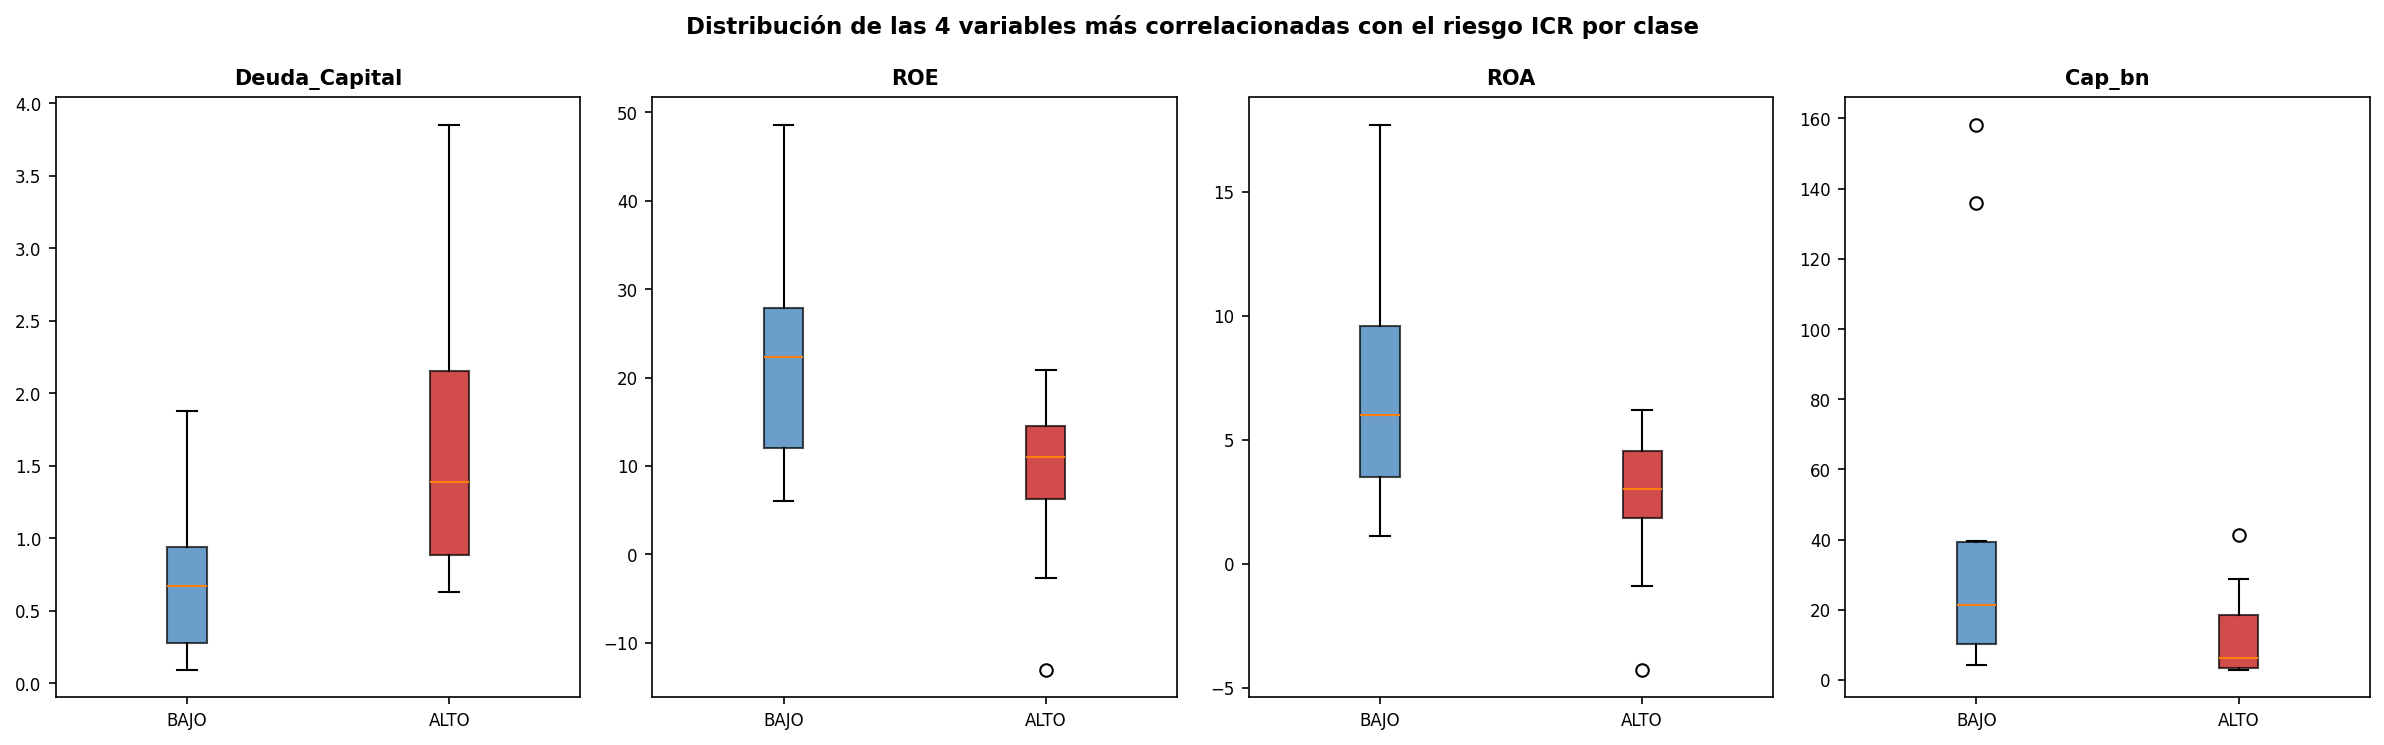

In [19]:
VARS_BOX = ['Deuda_Capital', 'ROE', 'ROA', 'Cap_bn']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, var in zip(axes, VARS_BOX):
    datos = [df[df['Y_RiesgoAlto']==0][var].values,
             df[df['Y_RiesgoAlto']==1][var].values]
    bp = ax.boxplot(datos, patch_artist=True, labels=['BAJO','ALTO'])
    bp['boxes'][0].set_facecolor('#2E75B6')
    bp['boxes'][1].set_facecolor('#C00000')
    for box in bp['boxes']: box.set_alpha(0.7)
    ax.set_title(var, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)
plt.suptitle('Distribución de las 4 variables más correlacionadas con ICR por clase de riesgo',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación de los boxplots:**

- **Deuda_Capital**: mediana del grupo ALTO (≈1,66) más del doble que el grupo BAJO (≈0,71)  
  → confirmación visual de que mayor apalancamiento implica menor ICR
- **ROE**: el grupo BAJO tiene mediana claramente superior (≈21,89% vs ≈9,12%)  
  → mayor rentabilidad sobre fondos propios implica mayor capacidad de cobertura
- **ROA**: misma dirección que ROE, separación también marcada
- **Cap_bn**: empresas de mayor capitalización tienden al grupo BAJO (más capacidad de cobertura)
- Estas diferencias visuales confirman que la clasificación ICR captura patrones financieros reales

### Perfil medio por clase de riesgo

In [20]:
vars_perfil = ['Deuda_Capital', 'ROA', 'EBITDA_Margin', 'Liquidez_Corriente',
               'Vol_Anual', 'Beta', 'ROE', 'Cap_bn']
perfil = df.groupby('Y_RiesgoAlto')[vars_perfil].mean().round(2)
perfil.index = perfil.index.map({0: 'BAJO (ICR ≥ 4,22)', 1: 'ALTO (ICR < 4,22)'})
print('Perfil medio por nivel de riesgo ICR:')
print(perfil.T.to_string())

Perfil medio por nivel de riesgo ICR:
                   BAJO (ICR ≥ 4,22)  ALTO (ICR < 4,22)
Deuda_Capital                   0.71               1.66
ROA                             6.97               2.59
EBITDA_Margin                  25.38              36.01
Liquidez_Corriente              1.31               1.21
Vol_Anual                       0.26               0.28
Beta                            0.67               0.84
ROE                            21.89               9.12
Cap_bn                         30.97              18.22


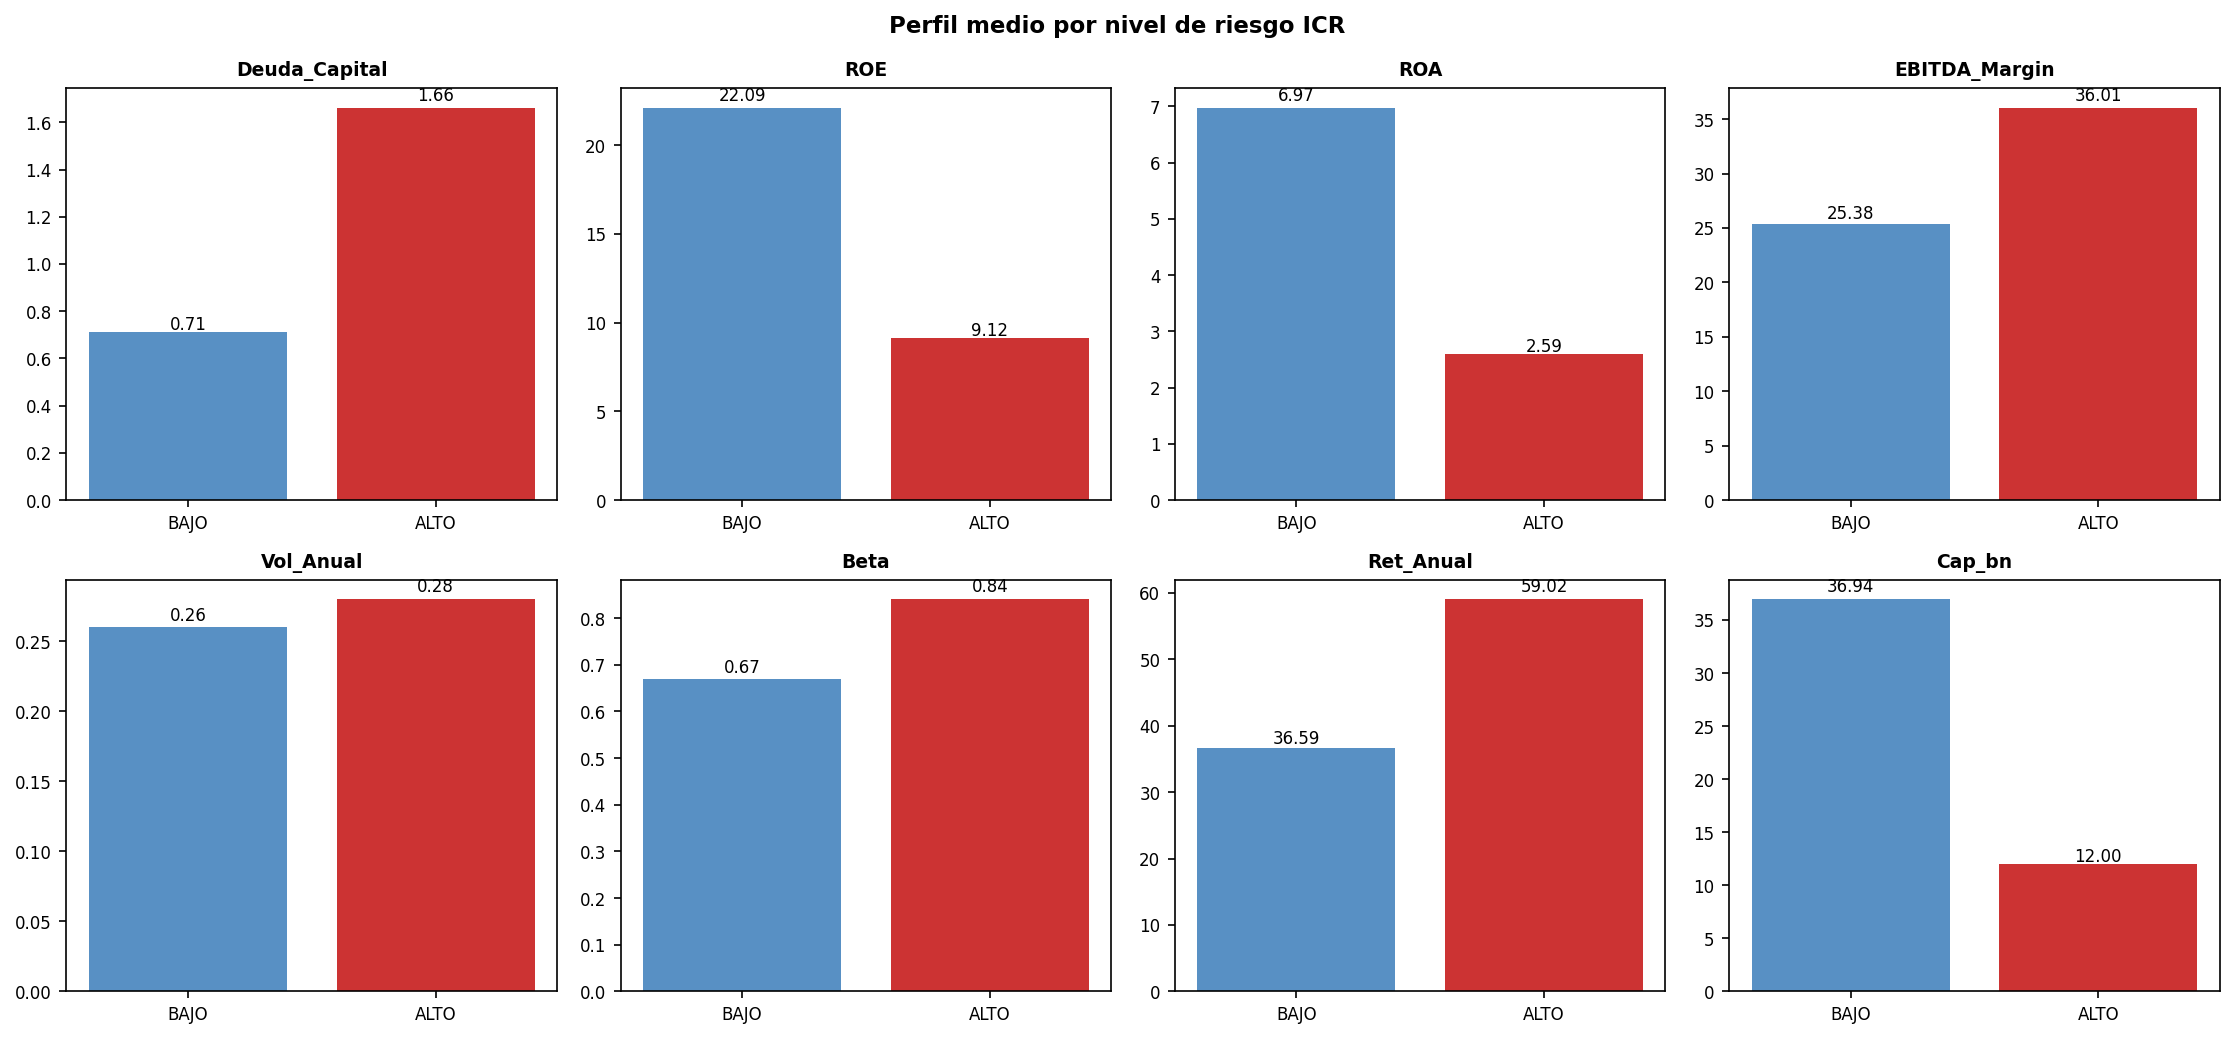

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()
for i, var in enumerate(vars_perfil):
    ax = axes[i]
    vals = [perfil.loc['BAJO (ICR ≥ 4,22)', var], perfil.loc['ALTO (ICR < 4,22)', var]]
    bars = ax.bar(['BAJO','ALTO'], vals, color=['#2E75B6','#C00000'], alpha=0.8)
    ax.set_title(var, fontsize=9, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                f'{val:.2f}', ha='center', fontsize=8)
    ax.tick_params(labelsize=8)
plt.suptitle('Perfil medio por nivel de riesgo ICR', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### Mapa bidimensional del riesgo ICR

Situamos las 29 empresas en el plano definido por las dos variables con mayor correlación  
con el ICR: **Deuda_Capital** (eje X) y **ROE** (eje Y). Cada empresa está coloreada según  
su clase Y_RiesgoAlto (rojo = ALTO, azul = BAJO).

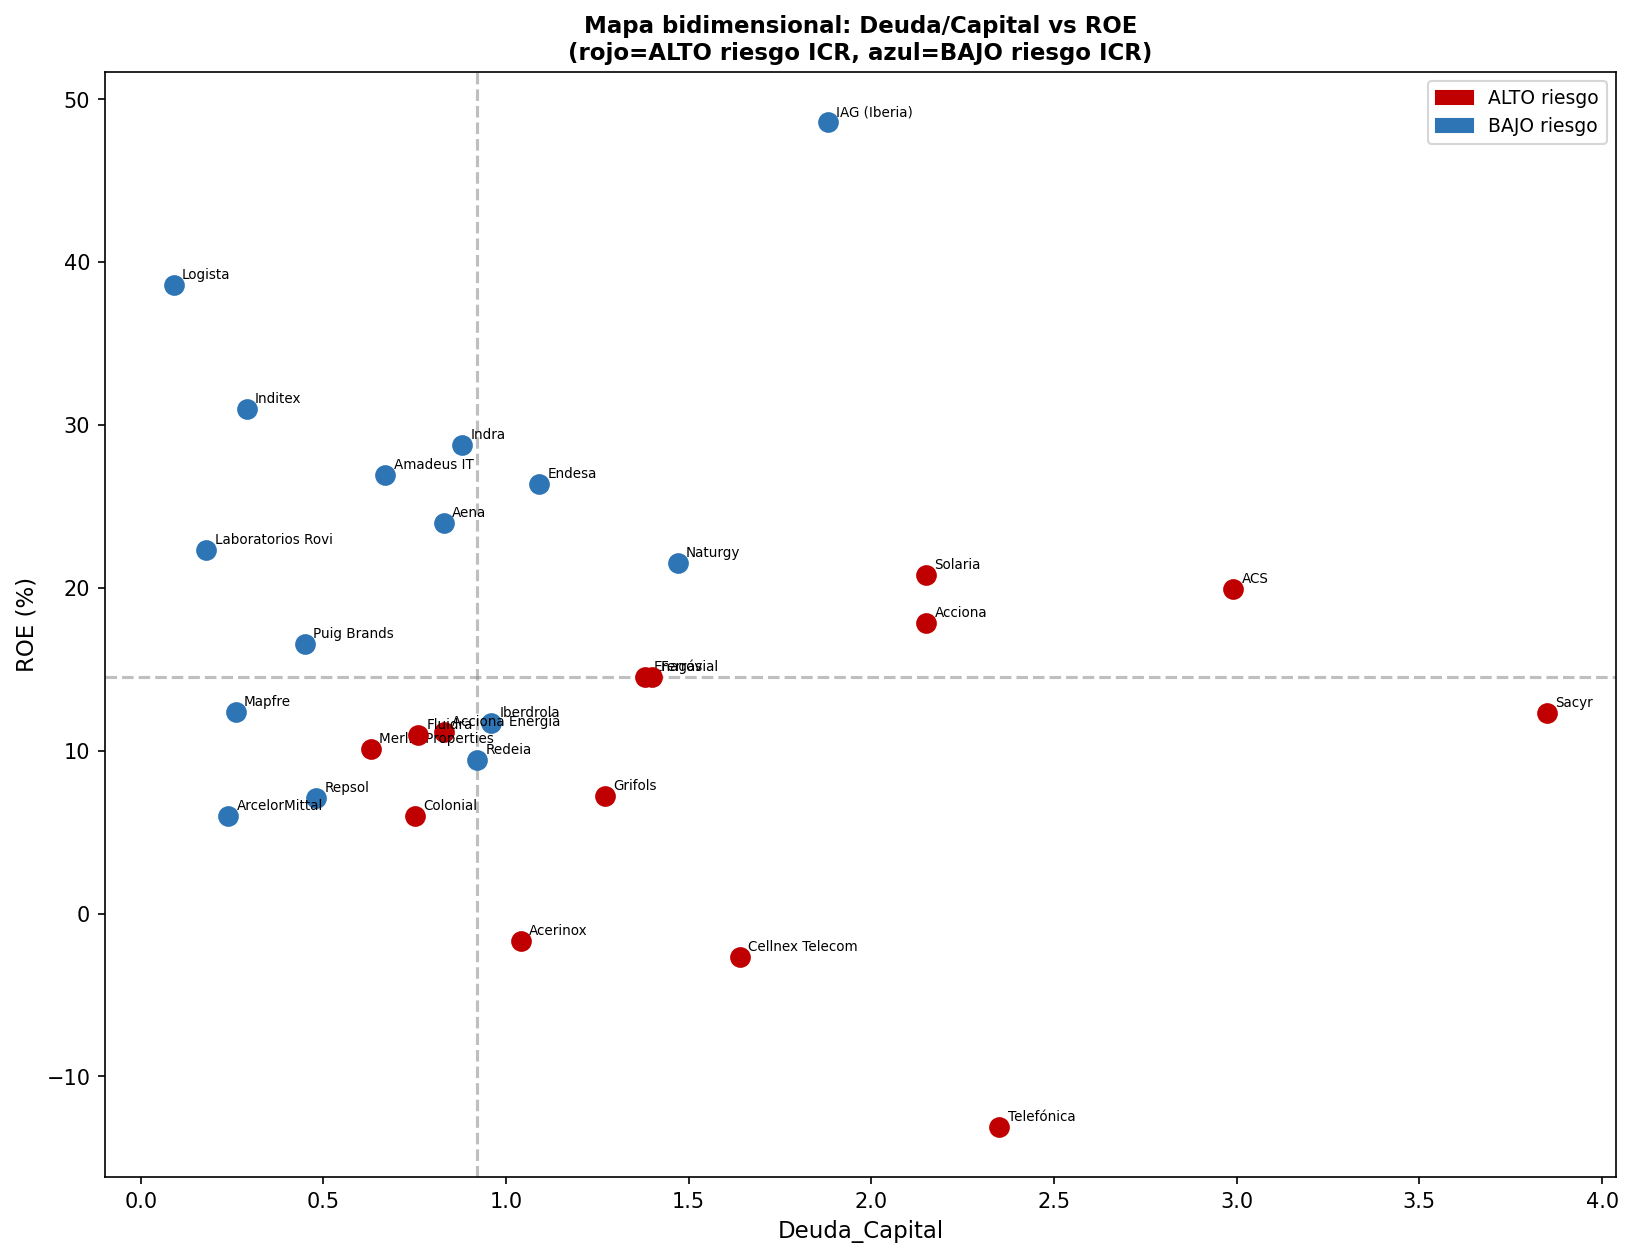

In [22]:
fig, ax = plt.subplots(figsize=(11, 8.5))
colors = ['#C00000' if v == 1 else '#2E75B6' for v in df['Y_RiesgoAlto']]
for idx_e, row in df.iterrows():
    color = '#C00000' if row['Y_RiesgoAlto'] == 1 else '#2E75B6'
    ax.scatter(row['Deuda_Capital'], row['ROE'], color=color, s=80, zorder=3)
    ax.annotate(row['Empresa'], (row['Deuda_Capital'], row['ROE']),
               fontsize=6.5, xytext=(4, 3), textcoords='offset points')
ax.axvline(df['Deuda_Capital'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(df['ROE'].median(), color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Deuda_Capital', fontsize=11)
ax.set_ylabel('ROE (%)', fontsize=11)
ax.set_title('Mapa de validación del ICR: Deuda/Capital vs ROE\n'
             '(rojo = ALTO riesgo ICR; azul = BAJO riesgo ICR)',
             fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#C00000', label='ALTO riesgo ICR'),
                   Patch(color='#2E75B6', label='BAJO riesgo ICR')], fontsize=9)
plt.tight_layout()
plt.show()

**Patrones que confirman la validez del ICR:**

1. **Cuadrante superior izquierdo** (baja deuda, alto ROE): Inditex, Rovi, Amadeus IT → todos BAJO riesgo
2. **Cuadrante inferior derecho** (alta deuda, bajo ROE): ACS, Acciona, Sacyr → todos ALTO riesgo
3. Las empresas en zona frontera (ICR 3–5x): Fluidra, Redeia, Enagás, Ferrovial → posición central
4. Cellnex: ROE bajo y Deuda_Capital alta → coherente con ICR de 0,74 (el más bajo del dataset)

### Matriz de correlación completa

La diagonal representa la correlación de cada variable consigo misma (= 1).  
La última fila/columna muestra la correlación de cada variable con Y_RiesgoAlto.

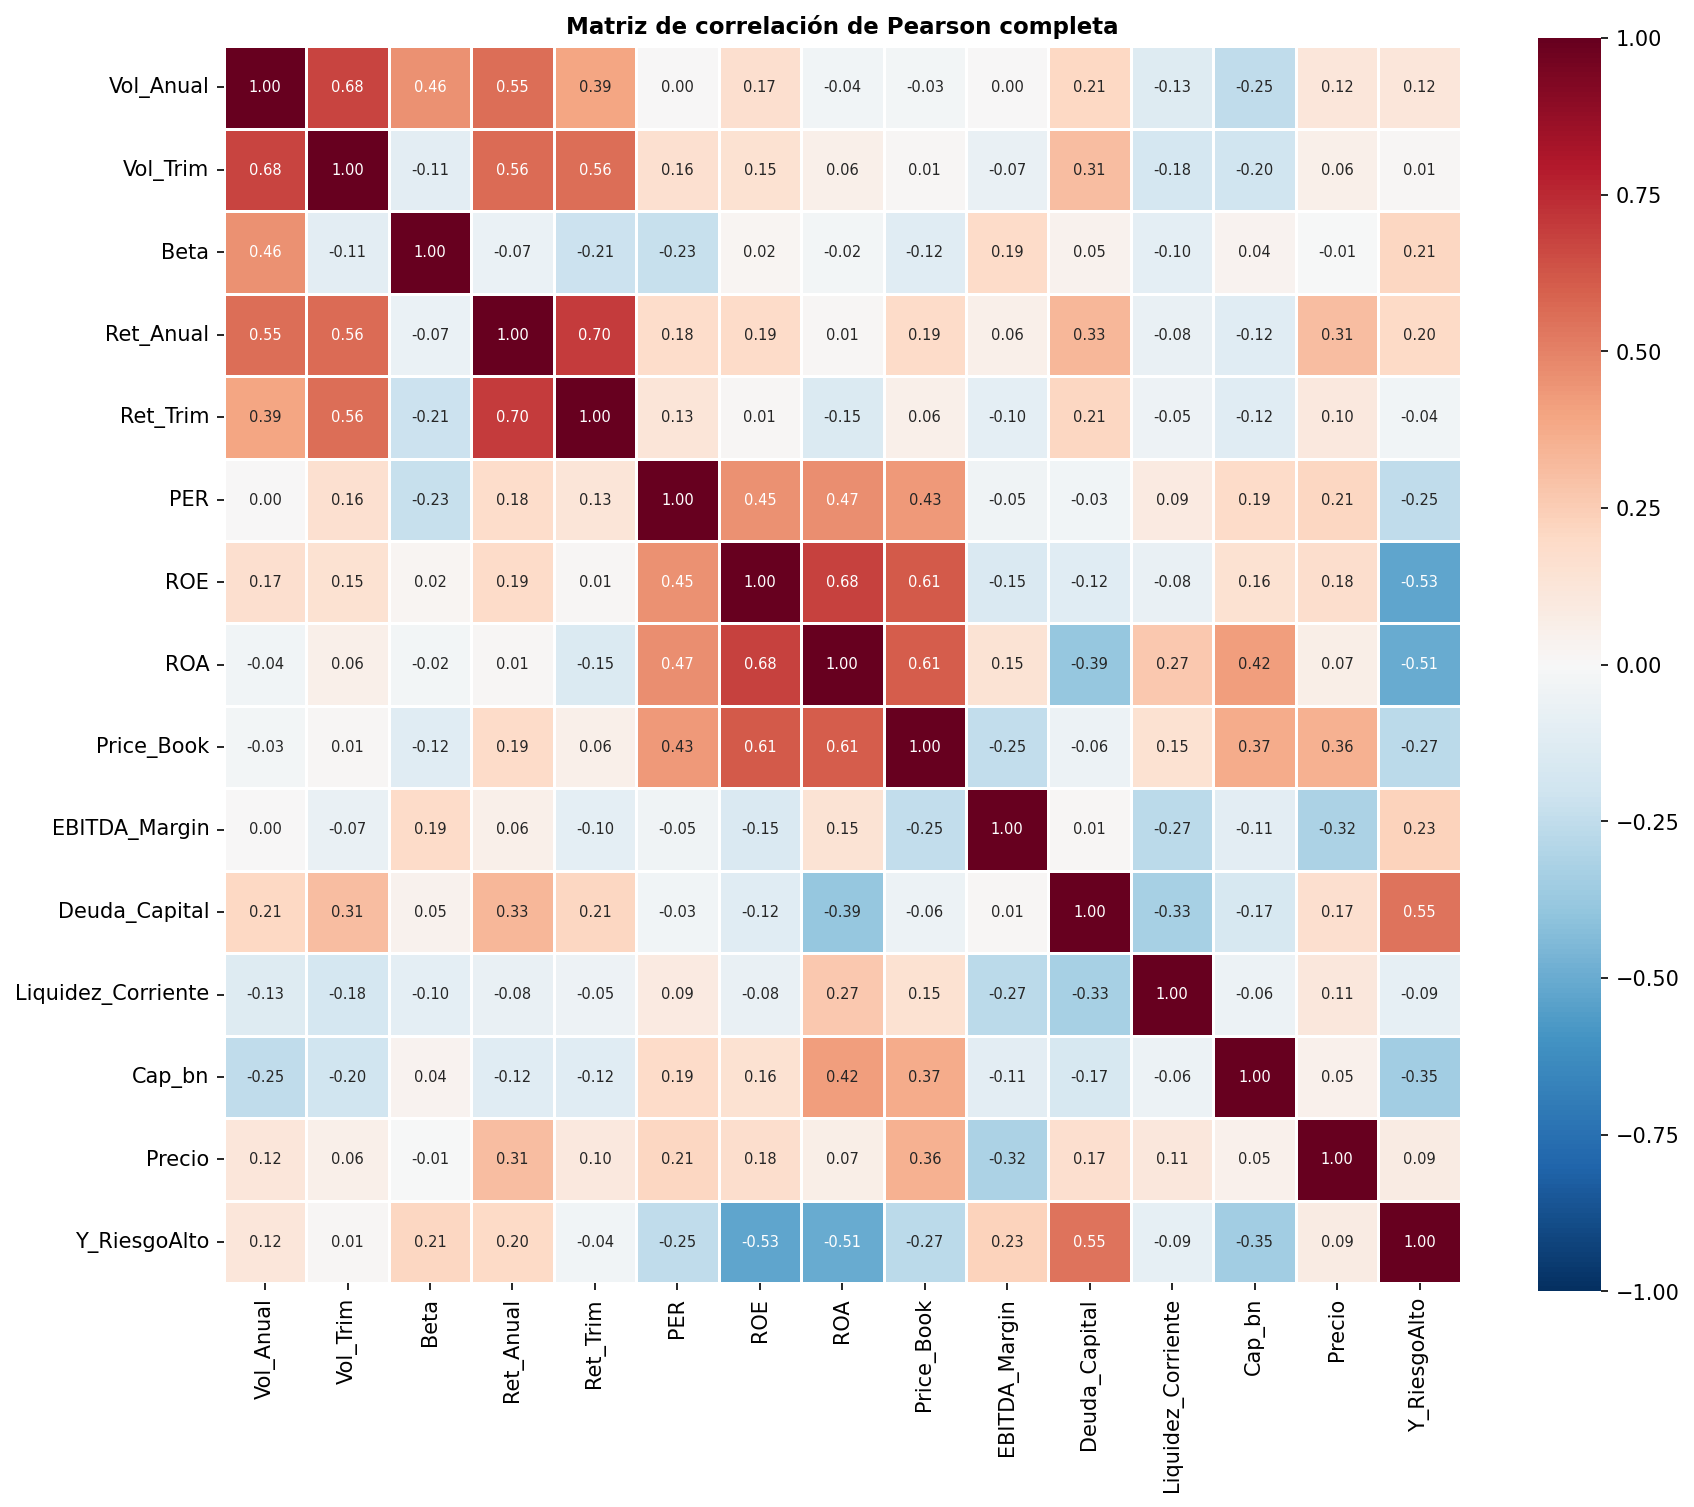

In [23]:
plt.figure(figsize=(12, 10))
sns.heatmap(corrs, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Matriz de correlación de Pearson completa', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Exportación del dataset final

El dataset final contiene:
- Las 14 variables numéricas normalizadas con StandardScaler
- `ICR`: el valor del ratio de cobertura original (sin normalizar, para interpretación)
- `Y_RiesgoAlto`: variable objetivo binaria (0 = BAJO, 1 = ALTO)

Se exporta a **`Dataset_Final_ICR_IBEX35.xlsx`** — input del notebook de Análisis del Dato.

In [24]:
# Dataset final para modelización
# Contenido: identificadores + 14 vars normalizadas + ICR (sin normalizar) + Y_RiesgoAlto
# EBIT y Gastos_Financieros NO se incluyen en el dataset de modelización
# (su función era construir el target — ya está en ICR e Y_RiesgoAlto)
columnas_finales = ['Empresa', 'Ticker', 'Sector'] + VARS_NUM + ['ICR', 'Y_RiesgoAlto']
df_export = df_final[columnas_finales].copy()

df_export.to_excel('Dataset_Final_ICR_IBEX35.xlsx', index=False)
print(f'Dataset final guardado: {df_export.shape[0]} filas x {df_export.shape[1]} columnas')
print(f'Nulos: {df_export.isnull().sum().sum()}')
print(f'Distribución Y_RiesgoAlto: {df_export["Y_RiesgoAlto"].value_counts().to_dict()}')
print(f'\nColumnas incluidas: {columnas_finales}')
print('EBIT y Gastos_Financieros NO incluidos: cumplieron su función al construir el ICR')
df_export.head()

Dataset final guardado: 29 filas x 19 columnas
Nulos: 0
Distribución Y_RiesgoAlto: {0: 15, 1: 14}

Columnas incluidas: ['Empresa', 'Ticker', 'Sector', 'Vol_Anual', 'Vol_Trim', 'Beta', 'Ret_Anual', 'Ret_Trim', 'PER', 'ROE', 'ROA', 'Price_Book', 'EBITDA_Margin', 'Deuda_Capital', 'Liquidez_Corriente', 'Cap_bn', 'Precio', 'ICR', 'Y_RiesgoAlto']
EBIT y Gastos_Financieros NO incluidos: cumplieron su función al construir el ICR


---

## Resumen del proceso de Ingeniería del Dato

| Etapa | Acción | Resultado |
|---|---|---|
| 3.2.1 Extracción | Carga de 29 empresas no financieras IBEX 35 | 29 × 17 columnas |
| 3.2.1 Target ICR | ICR = EBIT / Gastos_Financieros, umbral mediana 4,22 | 14 ALTO / 15 BAJO |
| **Clave** | **EBIT y Gastos_Financieros NO son predictores** | **Cero circularidad** |
| 3.2.2 Nulos | 4 nulos en Beta, EBITDA_Margin, Deuda_Capital, Liquidez_Corriente | Imputados por mediana |
| 3.2.2 Outliers | 29 outliers en 11 variables | Todos mantenidos (valores reales verificados) |
| 3.2.3 Normalización | StandardScaler | Media=0, std=1 en todas las variables |
| 3.2.3 Correlaciones | Pearson con Y_RiesgoAlto | Deuda_Capital (+0,55), ROE (−0,53), ROA (−0,51) |
| 3.2.4 Visualización | 6 figuras | Coherencia financiera validada |
| Exportación | Dataset_Final_ICR_IBEX35.xlsx | 29 × 19 columnas, 0 nulos |

**Dataset de salida listo para el notebook de Análisis del Dato.**